# Estimación de la edad cerebral a partir del EEG del sueño

Análisis exploratorio de datos — Sleep-EDF Database Expanded, subconjunto Sleep Cassette

Universidad de los Andes — Maestría en Inteligencia Artificial

La pregunta que orienta el análisis es si la señal de EEG registrada durante una noche de sueño
contiene información suficiente para estimar la edad del sujeto, base del Brain Age Index (BAI).

El recorrido va de la integridad de los datos a la viabilidad del planteamiento: primero se verifica
que los 153 registros sean utilizables, después se describen la muestra y la estructura de cada noche,
y por último se analiza el contenido en frecuencia de la señal y se establece una línea base de
estimación. Los cálculos costosos, la lectura de los 153 hipnogramas y la estimación espectral de las
153 noches, se realizan una sola vez y se reutilizan en todas las secciones.

# 1. Datos y configuración

## 1.1 Librerías y configuración

Se trabaja con el canal EEG Fpz-Cz, por ser el canal de referencia en la literatura sobre esta
base de datos y uno de los tres que efectivamente se registró a 100 Hz, como se verifica en la
sección 2.2.

In [1]:
import glob, os, warnings

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.signal import welch
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Guarda cada figura de plotly en dos formatos: interactivo (Jupyter) y PNG (GitHub, que no ejecuta JS)
pio.renderers.default = "plotly_mimetype+png"

# Los datos pueden estar en la carpeta compartida del repositorio (dvc pull) o en una carpeta local
RAIZ_DATOS = next(r for r in ("../Data", "../../Data", "Data", "data") if os.path.isdir(r + "/sleep-cassette"))
DATA_DIR = RAIZ_DATOS + "/sleep-cassette"
SUBJECTS_XLS = RAIZ_DATOS + "/SC-subjects.xls"
CANAL = "EEG Fpz-Cz"
EPOCA_S = 30           # duración estándar de una época de sueño
MARGEN_S = 30 * 60     # margen de vigilia que se conserva alrededor del sueño

# Equivalencia entre la nomenclatura del hipnograma (Rechtschaffen & Kales) y los estadios AASM
ETAPAS = {"Sleep stage W": "W", "Sleep stage 1": "N1", "Sleep stage 2": "N2", "Sleep stage 3": "N3",
          "Sleep stage 4": "N3", "Sleep stage R": "REM", "Movement time": "M", "Sleep stage ?": "?"}
NREM = {"Sleep stage 2", "Sleep stage 3", "Sleep stage 4"}
DORMIDO = ["N1", "N2", "N3", "REM"]
ETAPAS_SUENO = ["W"] + DORMIDO

# Bandas de frecuencia clásicas del EEG
BANDAS = {"delta": (0.5, 4), "theta": (4, 8), "alpha": (8, 12), "sigma": (12, 16), "beta": (16, 30)}
GRUPOS = {"25-45 años": (25, 45, "#2a78d6"), "46-69 años": (46, 69, "#1baf7a"),
          "70+ años": (70, 120, "#eb6834")}
COLOR = {"W": "#2a78d6", "N1": "#eb6834", "N2": "#1baf7a", "N3": "#eda100", "REM": "#e87ba4"}

print("Datos leídos desde:", RAIZ_DATOS)

Datos leídos desde: ../Data


## 1.2 Inventario de registros y metadatos

Cada noche está compuesta por un registro de señal (`*-PSG.edf`) y un hipnograma de anotaciones
(`*-Hypnogram.edf`) que comparten prefijo. El nombre del archivo identifica al sujeto y el número de
noche: `SC4001E0-PSG.edf` corresponde al sujeto 00, noche 1. La edad de cada sujeto, variable objetivo
de este análisis, se encuentra en `SC-subjects.xls`.

In [2]:
psg_files = sorted(glob.glob(DATA_DIR + "/*-PSG.edf"))
hyp_files = sorted(glob.glob(DATA_DIR + "/*-Hypnogram.edf"))

subjects = pd.read_excel(SUBJECTS_XLS).rename(columns={"sex (F=1)": "sex_code"})
subjects["sex"] = subjects["sex_code"].map({1: "F", 2: "M"})

claves = [(int(os.path.basename(p)[3:5]), int(os.path.basename(p)[5])) for p in psg_files]
registros = pd.DataFrame(claves, columns=["subject", "night"]).assign(psg=psg_files, hyp=hyp_files)
registros = registros.merge(subjects[["subject", "night", "age", "sex"]], on=["subject", "night"])

print("Registros PSG:", len(psg_files), "| Hipnogramas:", len(hyp_files))
print("Filas del archivo de metadatos:", len(subjects), "| Sujetos únicos:", subjects["subject"].nunique())
print("Registros con edad conocida:", registros["age"].notna().sum(), "de", len(registros))
registros.head()

Registros PSG: 153 | Hipnogramas: 153
Filas del archivo de metadatos: 153 | Sujetos únicos: 78
Registros con edad conocida: 153 de 153


,subject,night,psg,hyp,age,sex
0,0,1,../Data/sleep-cassette/SC4001E0-PSG.edf,../Data/sleep-cassette/SC4001EC-Hypnogram.edf,33,F
1,0,2,../Data/sleep-cassette/SC4002E0-PSG.edf,../Data/sleep-cassette/SC4002EC-Hypnogram.edf,33,F
2,1,1,../Data/sleep-cassette/SC4011E0-PSG.edf,../Data/sleep-cassette/SC4011EH-Hypnogram.edf,33,F
3,1,2,../Data/sleep-cassette/SC4012E0-PSG.edf,../Data/sleep-cassette/SC4012EC-Hypnogram.edf,33,F
4,2,1,../Data/sleep-cassette/SC4021E0-PSG.edf,../Data/sleep-cassette/SC4021EH-Hypnogram.edf,26,F


## 1.3 Tabla consolidada de anotaciones

Se leen los 153 hipnogramas una sola vez y se consolidan en una tabla única. Cada fila corresponde a
un segmento continuo de la noche en un mismo estadio, con su instante de inicio y su duración. Esta
tabla es la base de las secciones 2 y 5, y evita volver a abrir los archivos más adelante.

Una anotación no equivale a una época: un segmento de 900 segundos en N2 representa 30 épocas de
30 segundos. Por esa razón en adelante se trabaja con duraciones y no con conteos de anotaciones.

In [3]:
filas = []
for _, reg in registros.iterrows():
    ann = mne.read_annotations(reg["hyp"])
    filas += [{"subject": reg["subject"], "night": reg["night"], "onset_s": onset,
               "duration_s": duracion, "stage": ETAPAS[etapa]}
              for onset, duracion, etapa in zip(ann.onset, ann.duration, ann.description)]

dataset = pd.DataFrame(filas).merge(subjects[["subject", "night", "age", "sex"]], on=["subject", "night"])

print("Anotaciones consolidadas:", len(dataset), "| Noches:", dataset.groupby(["subject", "night"]).ngroups)
print("Épocas de 30 s equivalentes:", int(dataset["duration_s"].sum() / EPOCA_S))
dataset.head()

Anotaciones consolidadas: 22430 | Noches: 153
Épocas de 30 s equivalentes: 440640


,subject,night,onset_s,duration_s,stage,age,sex
0,0,1,0.0,30630.0,W,33,F
1,0,1,30630.0,120.0,N1,33,F
2,0,1,30750.0,390.0,N2,33,F
3,0,1,31140.0,30.0,N3,33,F
4,0,1,31170.0,30.0,N2,33,F


# 2. Integridad del conjunto de datos

Se verifica que los datos sean utilizables antes de describirlos: tipos, valores faltantes,
duplicados, consistencia entre los 153 registros y completitud de las anotaciones.

## 2.1 Tipos de dato, valores nulos y duplicados

Que un sujeto pase por la misma etapa varias veces en una noche no constituye un duplicado, es el
comportamiento normal del sueño. Solo se consideran duplicadas las filas idénticas en todas sus
columnas, incluido el instante de inicio.

In [4]:
print(dataset.dtypes, "\n")
print("Valores nulos por columna:")
print(dataset.isna().sum())
print("\nFilas duplicadas (exactas):", dataset.duplicated().sum())

subject         int64
night           int64
onset_s       float64
duration_s    float64
stage          object
age             int64
sex            object
dtype: object 

Valores nulos por columna:
subject       0
night         0
onset_s       0
duration_s    0
stage         0
age           0
sex           0
dtype: int64

Filas duplicadas (exactas): 0


## 2.2 Consistencia entre registros: canales, frecuencias y duración

Se revisa el encabezado de los 153 archivos PSG para confirmar que todos contienen los mismos canales.
La librería de lectura informa una frecuencia única para el archivo completo, pero el formato EDF
almacena el número de muestras por canal y por bloque, lo que permite recuperar la frecuencia real de
cada uno. Se contrasta además la duración de la señal con la del hipnograma que la acompaña.

In [5]:
cabeceras = [mne.io.read_raw_edf(ruta, preload=False) for ruta in psg_files]

print("Combinaciones distintas de canales:", len({tuple(c.ch_names) for c in cabeceras}))
print("Frecuencias que reporta la librería:", {c.info["sfreq"] for c in cabeceras})

dur_psg = pd.Series([c.n_times / c.info["sfreq"] / 3600 for c in cabeceras])
dur_hip = (dataset.assign(fin=dataset["onset_s"] + dataset["duration_s"])
           .groupby(["subject", "night"])["fin"].max() / 3600)
print(f"\nDuración de la señal PSG: mediana {dur_psg.median():.1f} h "
      f"(rango {dur_psg.min():.1f}-{dur_psg.max():.1f})")
print(f"Duración del hipnograma:  mediana {dur_hip.median():.1f} h "
      f"(rango {dur_hip.min():.1f}-{dur_hip.max():.1f})")

raw = mne.io.read_raw_edf(psg_files[0], preload=True)
pd.DataFrame({"canal": raw.ch_names,
              "frecuencia_real_hz": [n / EPOCA_S for n in raw._raw_extras[0]["n_samps"]]})

Combinaciones distintas de canales: 1
Frecuencias que reporta la librería: {100.0}

Duración de la señal PSG: mediana 23.0 h (rango 17.0-24.0)
Duración del hipnograma:  mediana 24.0 h (rango 24.0-24.0)


,canal,frecuencia_real_hz
0,EEG Fpz-Cz,100.0
1,EEG Pz-Oz,100.0
2,EOG horizontal,100.0
3,Resp oro-nasal,1.0
4,EMG submental,1.0
5,Temp rectal,1.0
6,Event marker,1.0


Los 153 registros son idénticos en canales y orden. Sin embargo, aunque la librería reporta 100 Hz
para todos, el encabezado revela que solo los dos canales de EEG y el de EOG se registraron
realmente a 100 Hz; la respiración, el EMG, la temperatura y el marcador de eventos están muestreados
a 1 Hz, y sus valores aparecen repetidos cien veces para completar el bloque.

Esto descarta esos cuatro canales para cualquier análisis de frecuencia: a 1 Hz no es posible observar
las oscilaciones de 12 a 16 Hz que caracterizan los husos de sueño.

La comparación de duraciones revela una segunda particularidad: la señal dura entre 17 y 24 horas
según el registro, mientras que todos los hipnogramas terminan exactamente a las 24 horas. El
excedente corresponde a un bloque final sin clasificar que no tiene señal detrás, por lo que debe
descartarse en el preprocesamiento.

## 2.3 Épocas sin clasificar

Se revisa qué proporción de cada registro quedó sin clasificar por el técnico (etiqueta `?`), lo que
permite identificar registros candidatos a revisión o exclusión. El cálculo se restringe al tramo que
tiene señal detrás: el bloque de relleno hasta las 24 horas descrito arriba no es trabajo pendiente
del técnico, y contarlo daría una cifra muy superior a la real.

Épocas sin clasificar por el técnico: media 0.3 %, máximo 28.1 %
Noches por encima del 20 %: 1 de 153
 subject  night  pct_sin_evaluar
       9      2             28.1
      76      2              4.7
      12      1              3.6


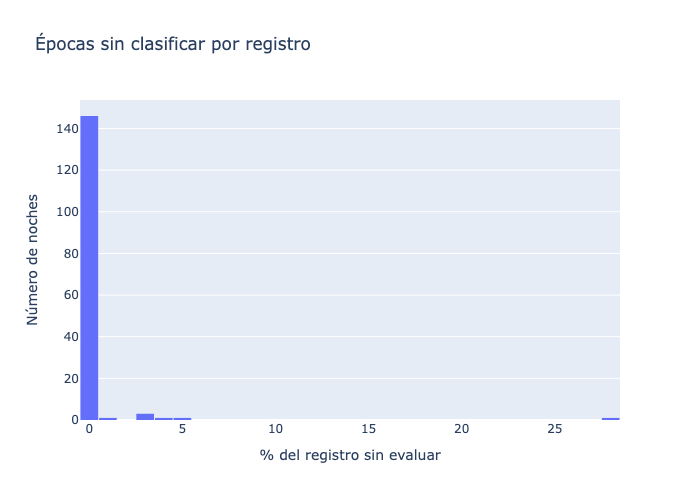

In [6]:
# Solo cuenta como "sin clasificar" lo que ocurre en el tramo que tiene señal detrás:
# el bloque de relleno hasta las 24 h no es trabajo pendiente del técnico.
dur_senal = {(s, n): c.n_times / c.info["sfreq"]
             for (s, n), c in zip(zip(registros["subject"], registros["night"]), cabeceras)}

filas_q = []
for (sujeto, noche), hip in dataset.groupby(["subject", "night"]):
    con_senal = (np.minimum(hip["onset_s"] + hip["duration_s"], dur_senal[(sujeto, noche)])
                 - hip["onset_s"]).clip(lower=0)
    filas_q.append({"subject": sujeto, "night": noche,
                    "pct_sin_evaluar": con_senal[hip["stage"] == "?"].sum() / con_senal.sum() * 100})
sin_evaluar = pd.DataFrame(filas_q)

print(f"Épocas sin clasificar por el técnico: media {sin_evaluar['pct_sin_evaluar'].mean():.1f} %, "
      f"máximo {sin_evaluar['pct_sin_evaluar'].max():.1f} %")
print(f"Noches por encima del 20 %: {(sin_evaluar['pct_sin_evaluar'] > 20).sum()} de {len(sin_evaluar)}")
print(sin_evaluar.nlargest(3, "pct_sin_evaluar").round(1).to_string(index=False))

px.histogram(sin_evaluar, x="pct_sin_evaluar", nbins=30,
             title="Épocas sin clasificar por registro",
             labels={"pct_sin_evaluar": "% del registro sin evaluar"}).update_layout(
    height=350, yaxis_title="Número de noches", bargap=0.05).show()

Las anotaciones están prácticamente completas: en promedio queda sin clasificar un 0,3 % de cada
registro, y una sola noche supera el 20 %. Esa noche es la única candidata a revisión antes de
entrenar. Si se contara también el relleno, la cifra media subiría al 5,7 % y aparecerían cuatro
noches aparentemente problemáticas que en realidad solo tienen la señal más corta.

# 3. Composición de la muestra

La etiqueta de este problema es una sola por sujeto, su edad, y no una por cada época de 30 segundos.
El tamaño efectivo de la muestra es por tanto el número de personas, y su composición condiciona todo
el diseño experimental.

## 3.1 Edad y sexo

Personas: 78 | {'F': 41, 'M': 37}
Edad: 25-101 años (media 58.8, mediana 57, desv. 22.1)

  25-45 años   n = 20  (26 %)
  46-69 años   n = 34  (44 %)
  70+ años     n = 24  (31 %)


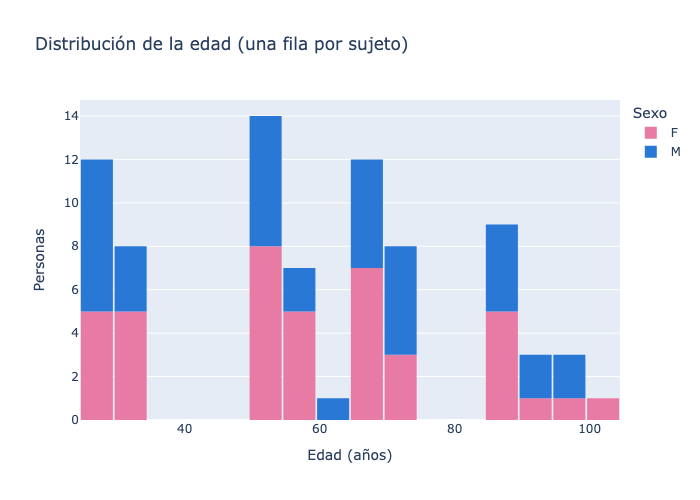

In [7]:
personas = registros.drop_duplicates("subject")

print(f"Personas: {len(personas)} | {personas['sex'].value_counts().to_dict()}")
print(f"Edad: {personas['age'].min()}-{personas['age'].max()} años "
      f"(media {personas['age'].mean():.1f}, mediana {personas['age'].median():.0f}, "
      f"desv. {personas['age'].std():.1f})\n")

for etiqueta, (desde, hasta, _) in GRUPOS.items():
    n = ((personas["age"] >= desde) & (personas["age"] <= hasta)).sum()
    print(f"  {etiqueta:12s} n = {n:2d}  ({n / len(personas) * 100:.0f} %)")

px.histogram(personas, x="age", nbins=20, color="sex", title="Distribución de la edad (una fila por sujeto)",
             labels={"age": "Edad (años)", "sex": "Sexo"}, color_discrete_map={"F": "#e87ba4", "M": "#2a78d6"}
             ).update_layout(height=380, yaxis_title="Personas", bargap=0.05).show()

Tramo de edad  Personas
     (20, 30]        13
     (30, 40]         7
     (40, 50]         2
     (50, 60]        20
     (60, 70]        13
     (70, 80]         7
     (80, 90]        10
    (90, 100]         5
   (100, 110]         1

Tramos de edad sin representar:
  de 35 a 49 años (15 años sin ningún sujeto)
  de 61 a 65 años (5 años sin ningún sujeto)
  de 75 a 84 años (10 años sin ningún sujeto)


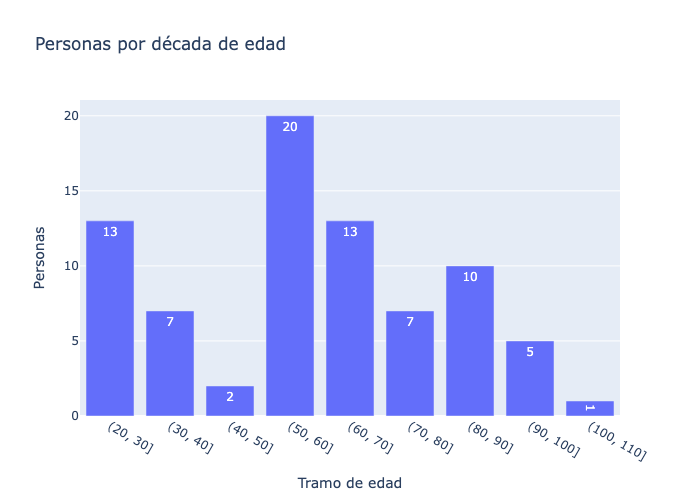

In [8]:
# Comprobación de uniformidad: ¿está la edad repartida o concentrada en pocos tramos?
tramos = pd.cut(personas["age"], bins=range(20, 120, 10))
conteo = tramos.value_counts().sort_index().rename_axis("Tramo de edad").reset_index(name="Personas")
conteo["Tramo de edad"] = conteo["Tramo de edad"].astype(str)
print(conteo.to_string(index=False))

# Tramos enteros sin ningún sujeto
edades = np.sort(personas["age"].unique())
print("\nTramos de edad sin representar:")
for a, b in zip(edades, edades[1:]):
    if b - a > 5:
        print(f"  de {a + 1} a {b - 1} años ({b - a - 1} años sin ningún sujeto)")

px.bar(conteo, x="Tramo de edad", y="Personas", text="Personas",
       title="Personas por década de edad").update_layout(height=350).show()

El rango es amplio, de 25 a 101 años, lo cual favorece el planteamiento: un modelo de edad cerebral
necesita variabilidad en la variable objetivo. La distribución, en cambio, no es continua: el estudio
reclutó por grupos etarios, de modo que quedan tramos enteros sin representar: el mayor va de los 35
a los 49 años y el segundo de los 75 a los 84, con un tercero menor entre los 61 y los 65. El modelo
no dispondrá de ejemplos en esos rangos, lo que se declara como limitación.

## 3.2 Noches por paciente

El estudio registró dos noches por paciente, salvo unas pocas excepciones. Esta estructura es
determinante para el diseño experimental: las dos noches de un mismo sujeto comparten la misma
etiqueta de edad y no son observaciones independientes, por lo que la partición de los datos debe
agrupar por paciente y no por registro.

Pacientes: 78 | Registros: 153
 Noches  Pacientes
      1          3
      2         75

Pacientes que NO tienen las dos noches:
 subject  night  age sex
      13      1   27   M
      36      2   51   M
      52      2   69   M


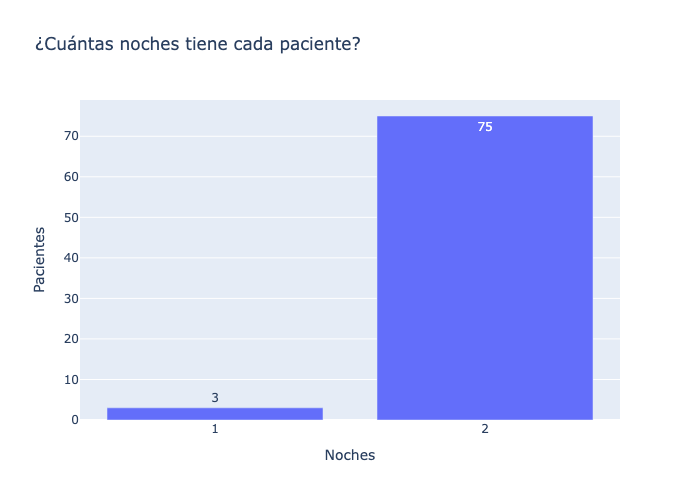

In [9]:
noches_por_sujeto = dataset.groupby("subject")["night"].nunique()
conteo_noches = noches_por_sujeto.value_counts().sort_index().rename_axis("Noches").reset_index(name="Pacientes")

print("Pacientes:", len(noches_por_sujeto), "| Registros:", dataset.groupby(["subject", "night"]).ngroups)
print(conteo_noches.to_string(index=False))

print("\nPacientes que NO tienen las dos noches:")
incompletos = noches_por_sujeto[noches_por_sujeto < 2].index
print(subjects[subjects["subject"].isin(incompletos)][["subject", "night", "age", "sex"]].to_string(index=False))

px.bar(conteo_noches, x="Noches", y="Pacientes", text="Pacientes", title="¿Cuántas noches tiene cada paciente?"
       ).update_layout(height=350, xaxis=dict(tickmode="array", tickvals=conteo_noches["Noches"])).show()

# 4. Los siete canales

Cada registro PSG contiene siete canales que miden fenómenos distintos del cuerpo durante el sueño:

| Canal | Qué mide |
|---|---|
| EEG Fpz-Cz | Actividad eléctrica cerebral, frente-centro |
| EEG Pz-Oz | Actividad eléctrica cerebral, parietal-occipital |
| EOG horizontal | Movimiento de los ojos |
| Resp oro-nasal | Flujo de aire por boca y nariz |
| EMG submental | Tensión del músculo bajo el mentón |
| Temp rectal | Temperatura corporal |
| Event marker | Marcas del equipo o del técnico |

## 4.1 Cómo se ve cada canal

Se toman dos minutos de sueño profundo del primer registro y se grafica cada canal en su propia
escala, ya que las magnitudes no son comparables entre sí.

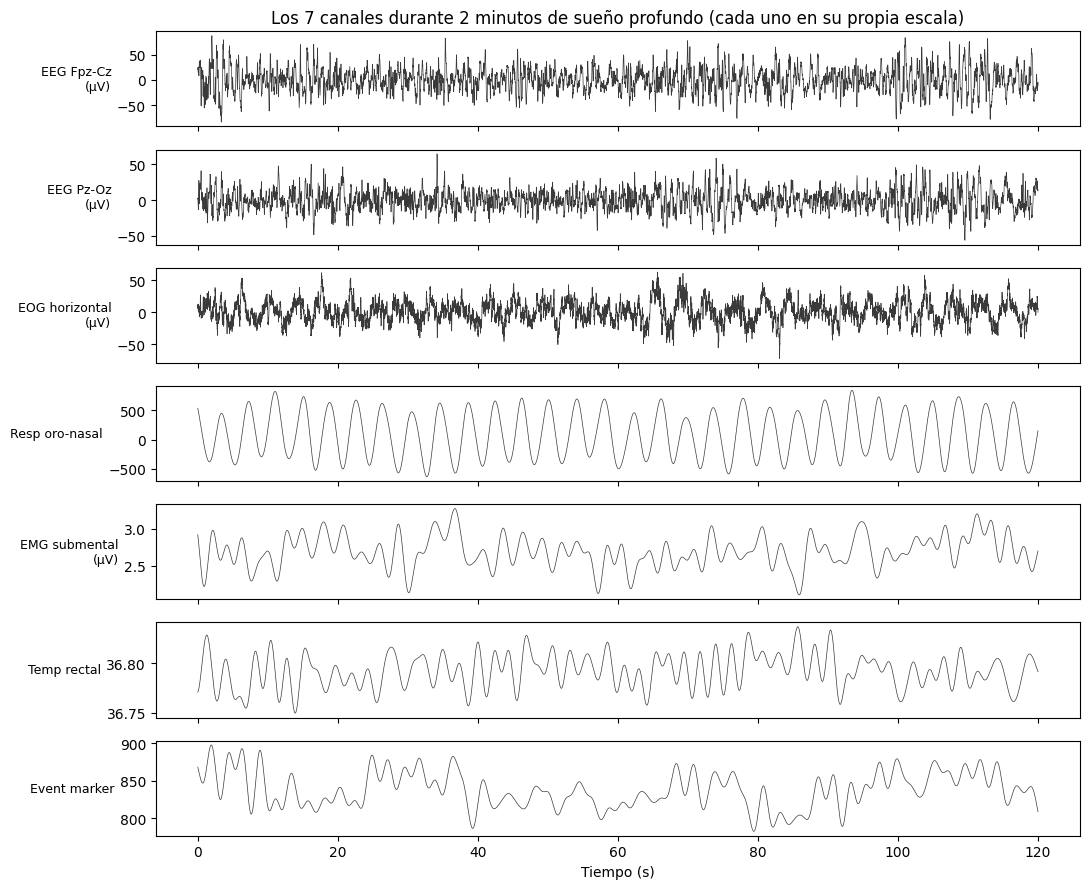

In [10]:
hipnograma = dataset[(dataset["subject"] == registros["subject"].iloc[0]) &
                     (dataset["night"] == registros["night"].iloc[0])]
fs = raw.info["sfreq"]

inicio = hipnograma[hipnograma["stage"] == "N3"]["onset_s"].iloc[0]  # sueño profundo
datos, t = raw.get_data(start=int(inicio * fs), stop=int((inicio + 120) * fs), return_times=True)

fig, ejes = plt.subplots(7, 1, figsize=(11, 9), sharex=True)
for senal_canal, nombre, eje in zip(datos, raw.ch_names, ejes):
    electrico = any(tipo in nombre for tipo in ("EEG", "EOG", "EMG"))
    eje.plot(t - t[0], senal_canal * 1e6 if electrico else senal_canal, linewidth=0.5, color="#3a3a3a")
    eje.set_ylabel(nombre + ("\n(µV)" if electrico else ""), rotation=0, ha="right", va="center", fontsize=9)

ejes[0].set_title("Los 7 canales durante 2 minutos de sueño profundo (cada uno en su propia escala)")
ejes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

## 4.2 Selección del canal de trabajo

De aquí en adelante se trabaja únicamente con EEG Fpz-Cz, por tres razones: es el canal frontal
con el que se describe la relación entre EEG y edad en la literatura, se registró efectivamente a
100 Hz, y es el canal más utilizado en los trabajos publicados sobre esta base de datos, lo que
permite comparar resultados.

La siguiente vista muestra dos horas de señal desde el inicio del sueño, con el fondo coloreado según
el estadio anotado. La barra inferior permite desplazarse y ampliar cualquier tramo.

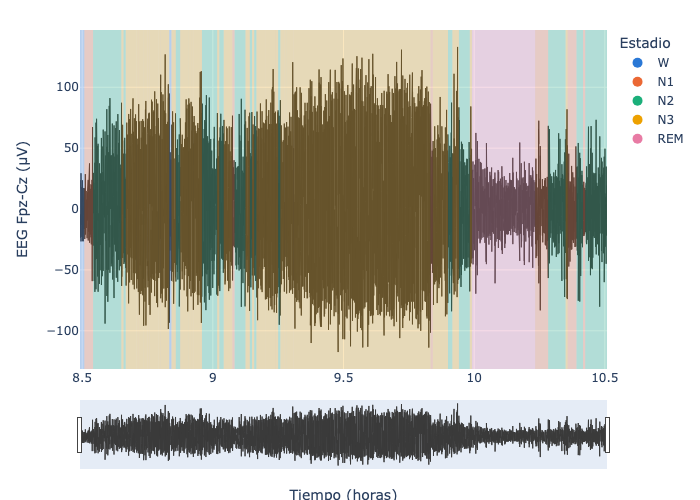

In [11]:
inicio_sueno = hipnograma[hipnograma["stage"] != "W"]["onset_s"].iloc[0]
t_inicio, t_fin = inicio_sueno - 60, inicio_sueno + 2 * 3600

senal, tiempos = raw.get_data(picks=[CANAL], start=int(t_inicio * fs), stop=int(t_fin * fs),
                              return_times=True)

fig = go.Figure(go.Scatter(x=tiempos[::16] / 3600, y=senal[0][::16] * 1e6, mode="lines",
                           line=dict(width=1, color="#3a3a3a"), showlegend=False))

# Franjas de color de fondo según el estadio de sueño
ventana = hipnograma[(hipnograma["onset_s"] + hipnograma["duration_s"] > t_inicio) &
                     (hipnograma["onset_s"] < t_fin)]
for _, fila in ventana.iterrows():
    fig.add_vrect(x0=max(fila["onset_s"], t_inicio) / 3600,
                  x1=min(fila["onset_s"] + fila["duration_s"], t_fin) / 3600,
                  fillcolor=COLOR.get(fila["stage"], "#999999"), opacity=0.25, line_width=0)

for etapa, color in COLOR.items():  # leyenda
    fig.add_scatter(x=[None], y=[None], mode="markers", marker=dict(size=10, color=color), name=etapa)

fig.update_layout(height=420, legend_title_text="Estadio", margin=dict(t=30, b=10),
                  yaxis_title=f"{CANAL} (µV)",
                  xaxis=dict(title="Tiempo (horas)", rangeslider_visible=True))
fig.show()

# 5. Estructura de la noche

Los registros del subconjunto Sleep Cassette son ambulatorios y abarcan un ciclo día-noche completo,
por lo que cubren en torno a un día entero. La mayor parte de ese tiempo es vigilia diurna, ajena al
sueño. Definir sobre qué tramo del registro se calcula cada medida es, por tanto, una decisión previa
a cualquier análisis.

## 5.1 Tres formas de delimitar la noche

Se comparan tres criterios para acotar el tramo del registro sobre el que se calcula cada medida:

| Delimitación | Criterio |
|---|---|
| Registro completo | Todo el archivo, sin recorte |
| Ventana ±30 min | Desde 30 minutos antes de la primera etapa de sueño hasta 30 minutos después de la última |
| Periodo de sueño | Desde la primera hasta la última etapa de sueño, sin margen |

La ventana con margen conserva el contexto de adormecimiento y despertar, útil para estudiar las
transiciones; el periodo de sueño sin margen es el adecuado para calcular porcentajes de arquitectura,
porque toda la vigilia que contiene es vigilia intra-sueño y no vigilia diurna.

Las tres se calculan en una sola pasada sobre la tabla consolidada, junto con las métricas de
arquitectura de cada noche.

In [12]:
def duracion_por_etapa(hip, inicio, fin):
    """Segundos de cada etapa dentro de la ventana [inicio, fin], recortando los segmentos del borde."""
    dentro = hip[(hip["onset_s"] + hip["duration_s"] > inicio) & (hip["onset_s"] < fin)].copy()
    dentro["duration_s"] = (np.minimum(dentro["onset_s"] + dentro["duration_s"], fin)
                            - np.maximum(dentro["onset_s"], inicio))
    return dentro.groupby("stage")["duration_s"].sum()


resumen, reparto = [], []
for (sujeto, noche), hip in dataset.groupby(["subject", "night"]):
    dormido = hip[hip["stage"].isin(DORMIDO)]
    if dormido.empty:
        continue

    inicio = dormido["onset_s"].iloc[0]
    fin = (dormido["onset_s"] + dormido["duration_s"]).iloc[-1]
    fin_registro = (hip["onset_s"] + hip["duration_s"]).max()

    delimitaciones = {"Registro completo": (0, fin_registro),
                      "Ventana ±30 min": (max(0, inicio - MARGEN_S), fin + MARGEN_S),
                      "Periodo de sueño": (inicio, fin)}
    for nombre, (desde, hasta) in delimitaciones.items():
        for etapa, segundos in duracion_por_etapa(hip, desde, hasta).items():
            reparto.append({"subject": sujeto, "night": noche, "delimitacion": nombre,
                            "stage": etapa, "segundos": segundos})

    # Métricas de arquitectura, siempre sobre el periodo de sueño
    periodo = duracion_por_etapa(hip, inicio, fin)
    tst = periodo.reindex(DORMIDO).fillna(0).sum()      # tiempo total de sueño
    en_cama = fin - inicio
    fila = {"subject": sujeto, "night": noche,
            "duracion_registro_h": fin_registro / 3600,
            "periodo_sueno_h": en_cama / 3600,
            "tst_h": tst / 3600,
            "eficiencia": tst / en_cama if en_cama else np.nan,
            "waso_min": periodo.get("W", 0) / 60,       # vigilia tras el inicio del sueño
            "latencia_rem_min": ((hip[hip["stage"] == "REM"]["onset_s"].min() - inicio) / 60
                                 if (hip["stage"] == "REM").any() else np.nan)}
    for etapa in DORMIDO:
        fila[f"pct_{etapa}"] = periodo.get(etapa, 0) / tst * 100 if tst else np.nan
    resumen.append(fila)

reparto = pd.DataFrame(reparto)
noches = pd.DataFrame(resumen).merge(subjects[["subject", "night", "age", "sex"]], on=["subject", "night"])

print(f"Noches procesadas: {len(noches)}")
print(f"Registro anotado:  mediana {noches['duracion_registro_h'].median():.1f} h")
print(f"Periodo de sueño:  mediana {noches['periodo_sueno_h'].median():.1f} h "
      f"({noches['periodo_sueno_h'].median() / noches['duracion_registro_h'].median() * 100:.0f} % del registro)")
print(f"Tiempo total de sueño: mediana {noches['tst_h'].median():.1f} h")
noches[["subject", "night", "age", "tst_h", "eficiencia", "waso_min", "pct_N2", "pct_N3", "pct_REM"]].head()

Noches procesadas: 153
Registro anotado:  mediana 24.0 h
Periodo de sueño:  mediana 8.4 h (35 % del registro)
Tiempo total de sueño: mediana 7.1 h


,subject,night,age,tst_h,eficiencia,waso_min,pct_N2,pct_N3,pct_REM
0,0,1,33,5.441667,0.905687,34.0,38.284839,33.690658,19.142420
1,0,2,33,7.866667,0.936508,31.5,39.512712,31.461864,22.775424
2,1,1,33,7.883333,0.962360,18.5,59.408034,11.099366,17.970402
3,1,2,33,8.533333,0.960600,21.0,64.453125,9.375000,17.187500
4,2,1,26,7.475000,0.991160,4.0,60.758082,10.590858,18.171683


La diferencia entre las cifras confirma el problema: el periodo de sueño ocupa poco más de un tercio
del registro anotado, y el tiempo efectivamente dormido dentro de él es todavía menor. Cualquier
característica calculada sobre el registro completo estaría midiendo mayoritariamente vigilia diurna.

## 5.2 Distribución de etapas y variabilidad entre registros

El primer gráfico muestra el efecto del recorte sobre el reparto de etapas: cuánto de lo que parece
desbalance de clases es en realidad vigilia diurna. El segundo responde si ese desbalance es un patrón
general de la base de datos o una particularidad de algunos registros.

delimitacion  Periodo de sueño  Registro completo  Ventana ±30 min
stage                                                             
W                         27.0               68.8             33.7
N1                        12.1                5.2             11.0
N2                        39.0               16.6             35.4
N3                         7.3                3.1              6.7
REM                       14.6                6.2             13.2


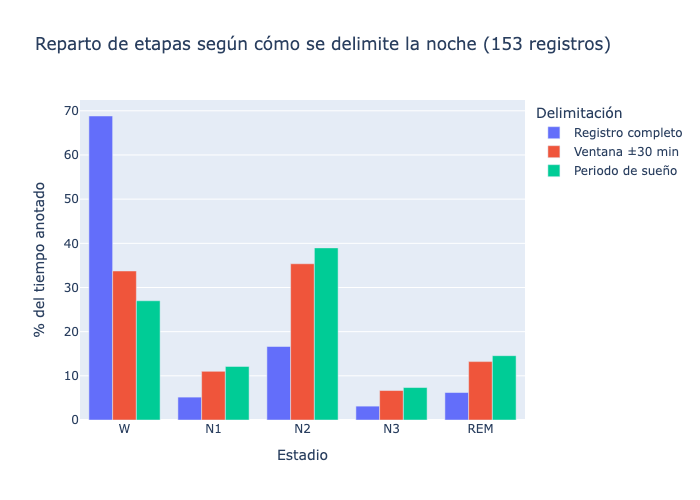

In [13]:
agregado = (reparto[reparto["stage"].isin(ETAPAS_SUENO)]
            .groupby(["delimitacion", "stage"])["segundos"].sum().reset_index())
agregado["pct"] = agregado.groupby("delimitacion")["segundos"].transform(lambda s: s / s.sum() * 100)
agregado["epocas_30s"] = (agregado["segundos"] / EPOCA_S).round().astype(int)

print(agregado.pivot(index="stage", columns="delimitacion", values="pct").round(1)
      .reindex(ETAPAS_SUENO).to_string())

px.bar(agregado, x="stage", y="pct", color="delimitacion", barmode="group",
       category_orders={"stage": ETAPAS_SUENO,
                        "delimitacion": ["Registro completo", "Ventana ±30 min", "Periodo de sueño"]},
       title="Reparto de etapas según cómo se delimite la noche (153 registros)",
       labels={"stage": "Estadio", "pct": "% del tiempo anotado", "delimitacion": "Delimitación"}
       ).update_layout(height=400).show()

Dispersión del porcentaje de cada etapa entre las 153 noches:
        min   25%   50%   75%   max
stage                              
W       0.5   6.3  15.9  36.5  68.4
N1      1.6   7.5  10.7  16.0  46.6
N2     10.3  32.7  43.7  52.5  70.9
N3      0.1   2.3   8.5  14.7  34.5
REM     2.2  11.2  14.6  20.5  29.7


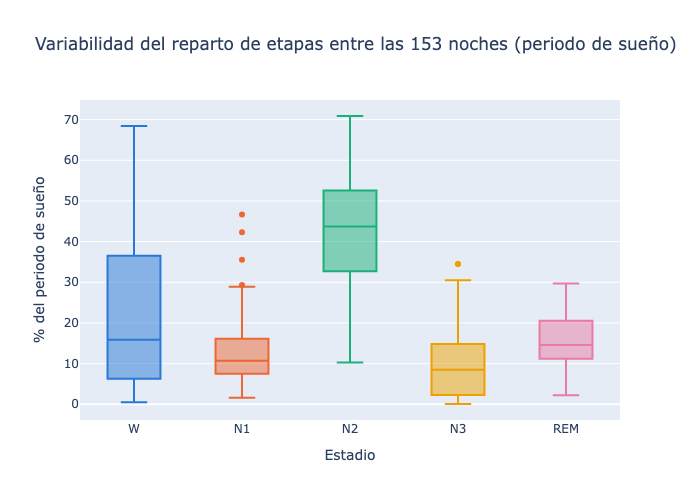

In [14]:
# Variabilidad entre sujetos: porcentaje de cada etapa dentro del periodo de sueño, noche por noche
periodo_noche = reparto[(reparto["delimitacion"] == "Periodo de sueño") &
                        (reparto["stage"].isin(ETAPAS_SUENO))].copy()
periodo_noche["pct"] = periodo_noche.groupby(["subject", "night"])["segundos"].transform(
    lambda s: s / s.sum() * 100)

print("Dispersión del porcentaje de cada etapa entre las 153 noches:")
print(periodo_noche.groupby("stage")["pct"].describe()[["min", "25%", "50%", "75%", "max"]]
      .reindex(ETAPAS_SUENO).round(1).to_string())

px.box(periodo_noche, x="stage", y="pct", color="stage", points="outliers",
       category_orders={"stage": ETAPAS_SUENO}, color_discrete_map=COLOR,
       title="Variabilidad del reparto de etapas entre las 153 noches (periodo de sueño)",
       labels={"stage": "Estadio", "pct": "% del periodo de sueño"}
       ).update_layout(height=400, showlegend=False).show()

El recorte reduce la vigilia de forma sustancial, pero el desbalance no desaparece: N2 sigue siendo
con diferencia la etapa más frecuente y N1 la más escasa. El desbalance es por tanto una propiedad del
sueño y no un artefacto del registro, y se observa de forma consistente en las 153 noches.

La dispersión entre noches es amplia, en particular en N3 y en la vigilia intra-sueño, y refleja
diferencias reales entre personas. Buena parte de esa dispersión está asociada a la edad, como se
verifica a continuación.

## 5.3 Arquitectura del sueño frente a la edad

Las métricas estructurales de la noche son conocidas por su variación con la edad y constituyen el
primer grupo de características candidatas para el modelo. Se promedian las dos noches de cada sujeto,
ya que no son observaciones independientes.

In [15]:
VARIABLES_ARQ = {"tst_h": "Tiempo total de sueño (h)", "eficiencia": "Eficiencia del sueño",
                 "waso_min": "Vigilia tras inicio del sueño (min)", "latencia_rem_min": "Latencia a REM (min)",
                 "pct_N1": "% N1", "pct_N2": "% N2", "pct_N3": "% N3 (sueño profundo)", "pct_REM": "% REM"}

por_sujeto = noches.groupby("subject").agg({"age": "first", "sex": "first",
                                            **{v: "mean" for v in VARIABLES_ARQ}}).reset_index()

print(f"Correlación con la edad (n = {len(por_sujeto)} sujetos)\n")
print(f"{'variable':34s} {'r':>7s} {'p':>9s}")
correlaciones = {}
for var, etiqueta in VARIABLES_ARQ.items():
    datos_var = por_sujeto[[var, "age"]].dropna()
    r, p = stats.pearsonr(datos_var[var], datos_var["age"])
    correlaciones[var] = r
    print(f"{etiqueta:34s} {r:+.3f} {p:9.4f}{'  *' if p < 0.05 else ''}")

Correlación con la edad (n = 78 sujetos)

variable                                 r         p
Tiempo total de sueño (h)          -0.063    0.5862
Eficiencia del sueño               -0.615    0.0000  *
Vigilia tras inicio del sueño (min) +0.571    0.0000  *
Latencia a REM (min)               +0.223    0.0493  *
% N1                               +0.637    0.0000  *
% N2                               -0.008    0.9415
% N3 (sueño profundo)              -0.421    0.0001  *
% REM                              -0.313    0.0053  *


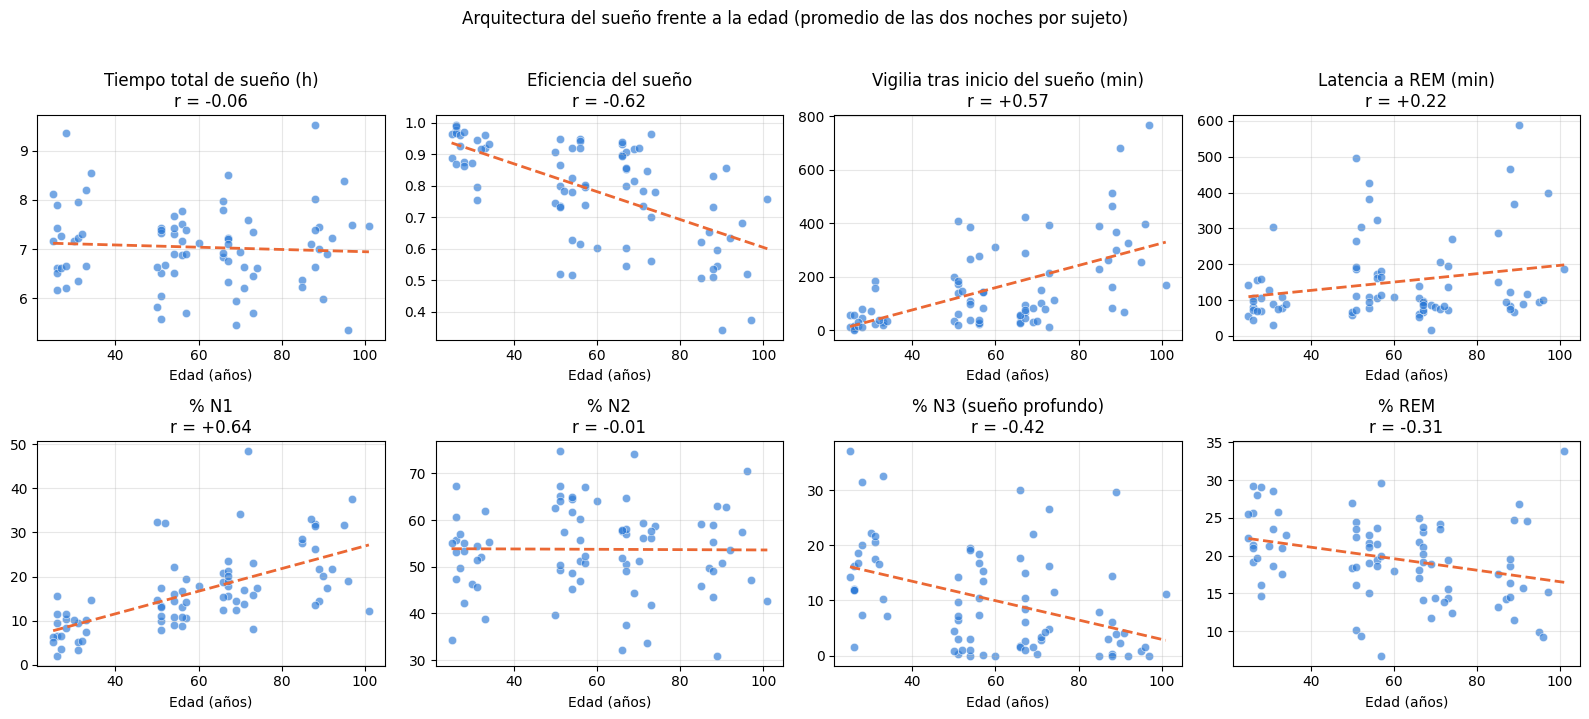

In [16]:
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
for eje, (var, etiqueta) in zip(ejes.ravel(), VARIABLES_ARQ.items()):
    datos_var = por_sujeto[[var, "age"]].dropna()
    eje.scatter(datos_var["age"], datos_var[var], alpha=0.65, color="#2a78d6",
                edgecolor="white", linewidth=0.5)
    eje.plot(sorted(datos_var["age"]),
             np.polyval(np.polyfit(datos_var["age"], datos_var[var], 1), sorted(datos_var["age"])),
             "--", color="#eb6834", linewidth=2)
    eje.set(xlabel="Edad (años)", title=f"{etiqueta}\nr = {correlaciones[var]:+.2f}")
    eje.grid(alpha=0.3)

plt.suptitle("Arquitectura del sueño frente a la edad (promedio de las dos noches por sujeto)", y=1.02)
plt.tight_layout()
plt.show()

Lo que cambia con la edad no es la cantidad de sueño sino su reparto. El tiempo total apenas varía
(r = −0,06, sin significancia), pero la eficiencia disminuye (r = −0,62), la vigilia dentro de la
noche aumenta (r = +0,57) y el sueño se desplaza hacia estadios más superficiales: el porcentaje de N1
sube (r = +0,64) mientras bajan el sueño profundo (r = −0,42) y el REM (r = −0,31). Al tratarse de una
muestra transversal, estas cifras describen diferencias entre personas de distinta edad y no la
evolución de un mismo sujeto.

El porcentaje de N1 es, de hecho, la característica con mayor correlación individual con la edad de
todo el análisis. Estas ocho variables se derivan solo del hipnograma, sin tocar la señal, y ya
constituyen un conjunto utilizable para el modelo.

# 6. Contenido espectral de la señal

Se descompone la señal en sus componentes de frecuencia mediante la transformada de Fourier, aplicada
con el método de Welch. El cálculo se restringe a épocas de sueño NREM repartidas a lo largo de la
noche: de cada registro se toman 30 épocas de 30 segundos distribuidas uniformemente entre todas las
disponibles, lo que evita que una fase concreta de la noche domine el resultado.

Este es el cálculo más costoso del notebook y se realiza una sola vez; sus resultados alimentan tanto
esta sección como la línea base de la sección 7.

## 6.1 Cálculo de los espectros

In [17]:
def espectro_de_la_noche(ruta_psg, ruta_hyp, n_epocas=30):
    """Espectro promedio de n_epocas de sueño NREM repartidas a lo largo de una noche."""
    ann = mne.read_annotations(ruta_hyp)
    registro = mne.io.read_raw_edf(ruta_psg, preload=False)
    frec = registro.info["sfreq"]

    inicios = [onset + EPOCA_S * k
               for onset, duracion, etapa in zip(ann.onset, ann.duration, ann.description)
               if etapa in NREM for k in range(int(duracion // EPOCA_S))]
    if len(inicios) < n_epocas:
        return None, None

    psds = []
    for i in np.linspace(0, len(inicios) - 1, n_epocas).astype(int):
        ini = int(inicios[i] * frec)
        muestras = registro.get_data(picks=[CANAL], start=ini, stop=ini + int(EPOCA_S * frec))[0]
        frecuencias, psd = welch(muestras, fs=frec, nperseg=int(4 * frec))
        psds.append(psd)
    return frecuencias, np.mean(psds, axis=0) * 1e12  # V²/Hz -> µV²/Hz


resultados = [espectro_de_la_noche(p, h) for p, h in zip(registros["psg"], registros["hyp"])]
validos = [i for i, (f, _) in enumerate(resultados) if f is not None]
frecs = resultados[validos[0]][0]
espectros = np.array([resultados[i][1] for i in validos])
edades_esp = registros.iloc[validos]["age"].values

print(f"Espectros calculados: {len(espectros)} de {len(registros)} noches")
print(f"Resolución en frecuencia: {frecs[1] - frecs[0]:.2f} Hz | rango 0-{frecs.max():.0f} Hz")

Espectros calculados: 153 de 153 noches
Resolución en frecuencia: 0.25 Hz | rango 0-50 Hz


## 6.2 Espectro promedio por grupo de edad

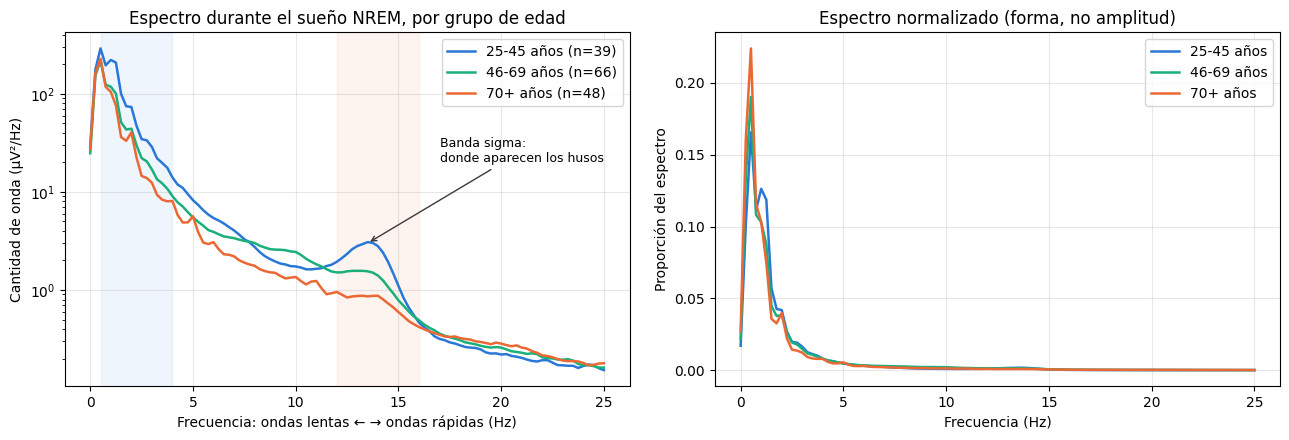

In [18]:
visible = frecs <= 25
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))

for etiqueta, (desde, hasta, color) in GRUPOS.items():
    grupo = (edades_esp >= desde) & (edades_esp <= hasta)
    ejes[0].semilogy(frecs[visible], espectros[grupo][:, visible].mean(axis=0),
                     color=color, linewidth=1.8, label=f"{etiqueta} (n={grupo.sum()})")
ejes[0].axvspan(0.5, 4, alpha=0.07, color="#2a78d6")
ejes[0].axvspan(12, 16, alpha=0.07, color="#eb6834")
ejes[0].annotate("Banda sigma:\ndonde aparecen los husos", xy=(13.5, 3), xytext=(17, 20), fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="#3a3a3a"))
ejes[0].set(xlabel="Frecuencia: ondas lentas ← → ondas rápidas (Hz)",
            ylabel="Cantidad de onda (µV²/Hz)",
            title="Espectro durante el sueño NREM, por grupo de edad")
ejes[0].legend()

# Mismo espectro normalizado: aísla el cambio de forma del cambio de amplitud global
for etiqueta, (desde, hasta, color) in GRUPOS.items():
    grupo = (edades_esp >= desde) & (edades_esp <= hasta)
    medio = espectros[grupo][:, visible].mean(axis=0)
    ejes[1].plot(frecs[visible], medio / medio.sum(), color=color, linewidth=1.8, label=etiqueta)
ejes[1].set(xlabel="Frecuencia (Hz)", ylabel="Proporción del espectro",
            title="Espectro normalizado (forma, no amplitud)")
ejes[1].legend()

[eje.grid(alpha=0.3) for eje in ejes]
plt.tight_layout()
plt.show()

El panel izquierdo muestra la amplitud absoluta y el derecho la forma del espectro una vez eliminada la
amplitud global. La distinción importa: una parte de la caída con la edad se debe a la reducción
general de amplitud del EEG, y otra a un cambio real en la composición de la señal. El pico alrededor
de los 13 Hz, correspondiente a los husos de sueño, se atenúa en el grupo intermedio y prácticamente
desaparece en los mayores de 70 años, y esa pérdida persiste tras normalizar.

## 6.3 Características espectrales frente a la edad

De cada espectro se derivan dos familias de características por banda, que responden a preguntas
distintas y que la sección anterior ya anticipó al mostrar el espectro absoluto y el normalizado:

- Absolutas (`abs_`): cuánta actividad hay en la banda, en escala logarítmica. Responden a
  *¿cuánta onda queda?* y capturan la pérdida general de amplitud.
- Relativas (`rel_`): qué proporción del espectro total ocupa la banda. Responden a *¿cómo se
  reparte la actividad que queda?* y capturan el cambio de forma con independencia de la amplitud.

Se añaden la potencia total y la frecuencia por debajo de la cual se acumula el 95 % de la potencia
(SEF95). Ambas familias se conservan porque miden fenómenos diferentes: con la edad el EEG pierde
amplitud y además cambia de composición, y una sola familia no distingue los dos efectos.

In [19]:
mascara_total = (frecs >= 0.5) & (frecs <= 30)
total = espectros[:, mascara_total].sum(axis=1)

bandas = pd.DataFrame({"subject": registros.iloc[validos]["subject"].values,
                       "night": registros.iloc[validos]["night"].values,
                       "age": edades_esp,
                       "potencia_total_log": np.log10(total)})
for nombre, (desde, hasta) in BANDAS.items():
    mascara = (frecs >= desde) & (frecs < hasta)
    potencia = espectros[:, mascara].sum(axis=1)
    bandas[f"abs_{nombre}"] = np.log10(potencia)   # cuánta onda hay
    bandas[f"rel_{nombre}"] = potencia / total     # qué proporción del espectro ocupa

acumulado = np.cumsum(espectros[:, mascara_total], axis=1)
bandas["sef95"] = frecs[mascara_total][np.argmax(acumulado >= 0.95 * acumulado[:, [-1]], axis=1)]

espectral_sujeto = bandas.groupby("subject").mean().reset_index().drop(columns="night")

print(f"Correlación con la edad (n = {len(espectral_sujeto)} sujetos)\n")
print(f"{'banda':10s} {'absoluta (r)':>14s} {'relativa (r)':>14s}")
for nombre in BANDAS:
    r_abs, p_abs = stats.pearsonr(espectral_sujeto[f"abs_{nombre}"], espectral_sujeto["age"])
    r_rel, p_rel = stats.pearsonr(espectral_sujeto[f"rel_{nombre}"], espectral_sujeto["age"])
    print(f"{nombre:10s} {r_abs:+13.3f}{'*' if p_abs < 0.05 else ' '} "
          f"{r_rel:+13.3f}{'*' if p_rel < 0.05 else ' '}")

for col in ("potencia_total_log", "sef95"):
    r, p = stats.pearsonr(espectral_sujeto[col], espectral_sujeto["age"])
    print(f"\n{col:20s} r = {r:+.3f} (p = {p:.1e})")

Correlación con la edad (n = 78 sujetos)

banda        absoluta (r)   relativa (r)
delta             -0.365*        +0.019 
theta             -0.416*        -0.082 
alpha             -0.254*        +0.090 
sigma             -0.502*        -0.294*
beta              +0.007         +0.398*

potencia_total_log   r = -0.375 (p = 7.1e-04)

sef95                r = +0.007 (p = 9.5e-01)


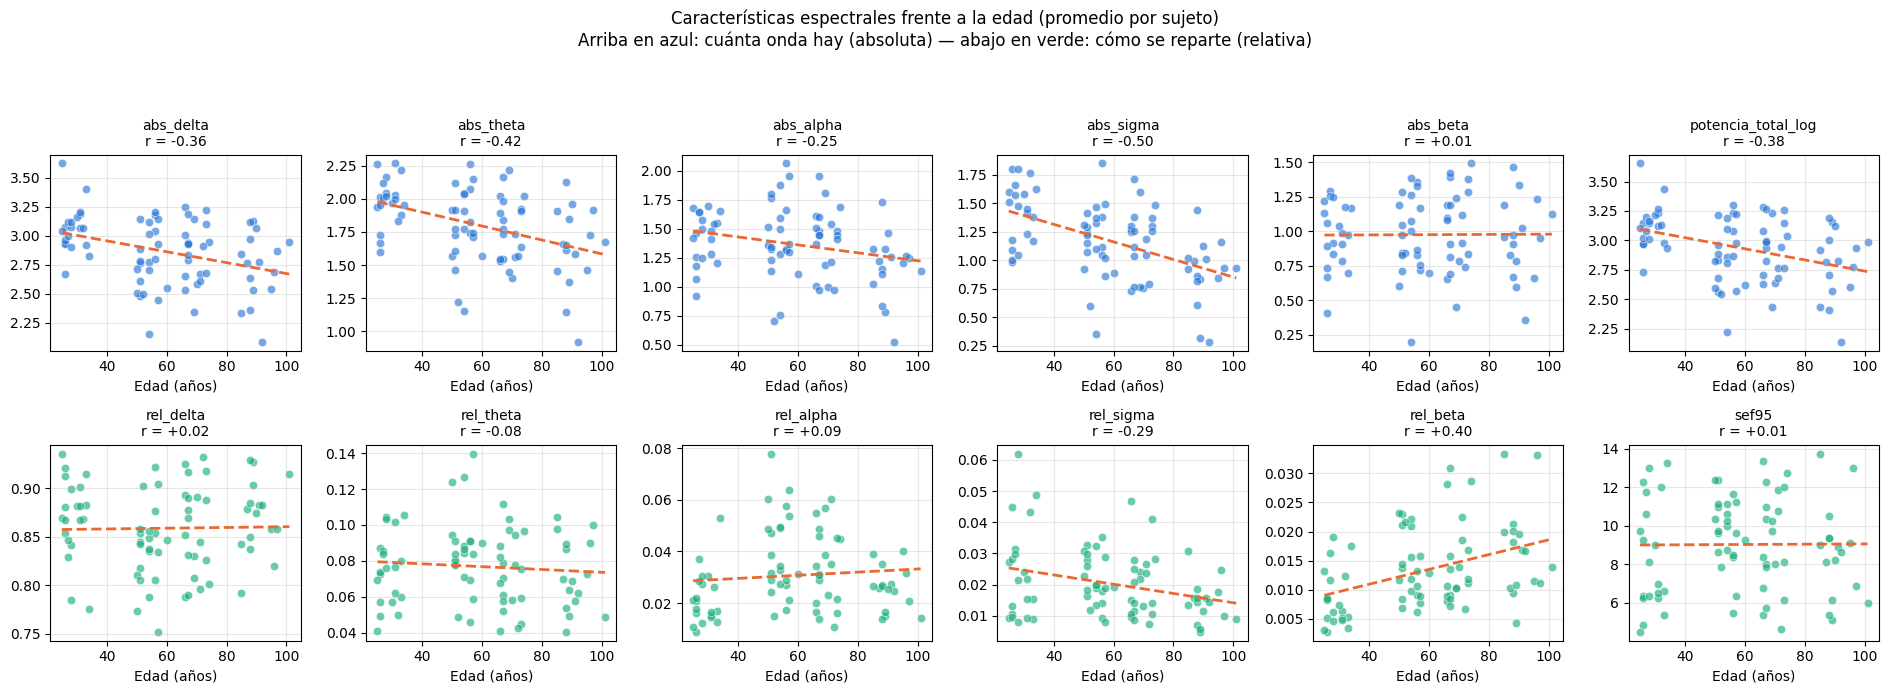

In [20]:
caracteristicas = ([f"abs_{n}" for n in BANDAS] + ["potencia_total_log"]
                   + [f"rel_{n}" for n in BANDAS] + ["sef95"])

fig, ejes = plt.subplots(2, 6, figsize=(19, 6.5))
for eje, col in zip(ejes.ravel(), caracteristicas):
    r, _ = stats.pearsonr(espectral_sujeto[col], espectral_sujeto["age"])
    eje.scatter(espectral_sujeto["age"], espectral_sujeto[col], alpha=0.65,
                color="#2a78d6" if col.startswith("abs_") or col == "potencia_total_log" else "#1baf7a",
                edgecolor="white", linewidth=0.5)
    eje.plot(sorted(espectral_sujeto["age"]),
             np.polyval(np.polyfit(espectral_sujeto["age"], espectral_sujeto[col], 1),
                        sorted(espectral_sujeto["age"])),
             "--", color="#eb6834", linewidth=2)
    eje.set(xlabel="Edad (años)")
    eje.set_title(f"{col}\nr = {r:+.2f}", fontsize=10)
    eje.grid(alpha=0.3)

plt.suptitle("Características espectrales frente a la edad (promedio por sujeto)\n"
             "Arriba en azul: cuánta onda hay (absoluta) — abajo en verde: cómo se reparte (relativa)",
             y=1.06)
plt.tight_layout()
plt.show()

Las dos familias no son intercambiables. En términos absolutos la actividad cae con la edad en casi
todas las bandas, y la caída más marcada es la de la banda sigma, la característica espectral con
mayor correlación individual con la edad. En términos relativos ese patrón se reordena: delta y
theta dejan de ser significativas, porque su descenso absoluto va acompañado del descenso general, y
en cambio beta pasa a crecer, ya que al perderse las ondas lentas y la actividad sigma gana peso
dentro del espectro.

Leídas juntas, ambas describen el mismo fenómeno: el EEG del sueño se hace más débil y más rápido con
la edad.

# 7. Viabilidad: línea base de estimación de la edad

Se comprueba si las características descritas permiten estimar la edad, mediante un modelo lineal
regularizado (Ridge) sobre las variables de arquitectura y las espectrales. No se busca aquí un modelo
definitivo, sino establecer una referencia que justifique o descarte el planteamiento del
micro-proyecto.

La validación cruzada agrupa por sujeto: las dos noches de una misma persona nunca quedan repartidas
entre entrenamiento y prueba, ya que comparten la misma etiqueta y producirían fuga de información.

## 7.1 Línea base con regresión Ridge

In [21]:
datos = por_sujeto.merge(espectral_sujeto, on=["subject", "age"]).dropna()
COLUMNAS = [c for c in datos.columns if c not in ("subject", "age", "sex")]

X = datos[COLUMNAS].values
y = datos["age"].values
grupos = datos["subject"].values

modelo = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))
prediccion = cross_val_predict(modelo, X, y, groups=grupos, cv=GroupKFold(n_splits=5))

mae = np.mean(np.abs(prediccion - y))
r, p = stats.pearsonr(prediccion, y)
r2 = 1 - np.sum((y - prediccion) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Sujetos: {len(y)} | Características: {len(COLUMNAS)}")
print(f"\nError absoluto medio (MAE): {mae:.1f} años")
print(f"Correlación edad real vs. estimada: r = {r:.3f} (p = {p:.2e})")
print(f"R²: {r2:.3f}")
print(f"\nReferencia: predecir siempre la edad media daría un MAE de "
      f"{np.mean(np.abs(y - y.mean())):.1f} años")

Sujetos: 78 | Características: 20

Error absoluto medio (MAE): 10.2 años
Correlación edad real vs. estimada: r = 0.820 (p = 4.64e-20)
R²: 0.672

Referencia: predecir siempre la edad media daría un MAE de 18.3 años


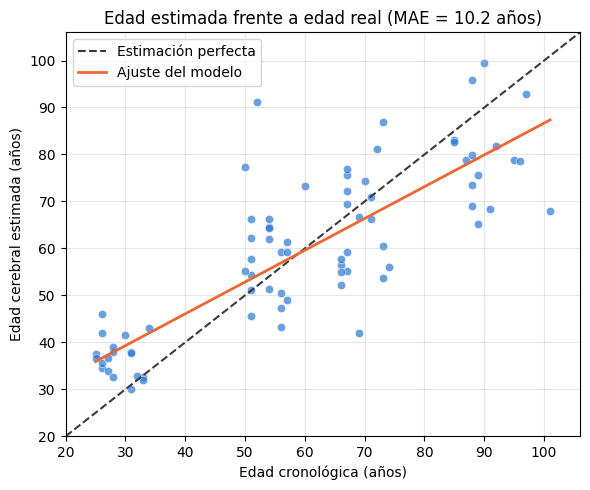

In [22]:
limites = [y.min() - 5, y.max() + 5]

plt.figure(figsize=(6, 5))
plt.scatter(y, prediccion, alpha=0.7, color="#2a78d6", edgecolor="white", linewidth=0.5)
plt.plot(limites, limites, "--", color="#3a3a3a", linewidth=1.5, label="Estimación perfecta")
plt.plot(sorted(y), np.polyval(np.polyfit(y, prediccion, 1), sorted(y)),
         color="#eb6834", linewidth=2, label="Ajuste del modelo")
plt.xlabel("Edad cronológica (años)")
plt.ylabel("Edad cerebral estimada (años)")
plt.title(f"Edad estimada frente a edad real (MAE = {mae:.1f} años)")
plt.xlim(limites); plt.ylim(limites)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El modelo se equivoca en promedio 10,2 años, frente a los 18,3 que costaría predecir siempre la edad
media. Es decir, reduce el error casi a la mitad usando únicamente el hipnograma y el espectro de una
noche, con un modelo lineal y validando por sujeto. No es un resultado clínicamente utilizable, pero
sí resuelve la pregunta que motivaba el análisis: la señal contiene información sobre la edad, y es
suficiente para sostener el planteamiento del micro-proyecto.

La nube de puntos muestra también el límite del enfoque: la recta ajustada es menos inclinada que la
diagonal, señal de que el modelo tiende a acercar sus estimaciones a la media. Ese efecto es el que se
examina a continuación.

## 7.2 El Brain Age Index y su sesgo

El BAI es la diferencia entre la edad estimada y la edad real del sujeto. Un valor positivo indica un
cerebro que aparenta más años de los que tiene, y uno negativo lo contrario. Antes de usarlo conviene
comprobar si el índice se comporta de forma neutral a lo largo del rango de edad.

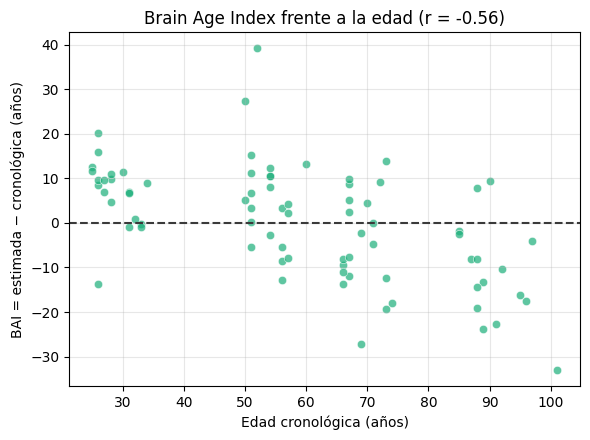

In [23]:
bai = prediccion - y

plt.figure(figsize=(6, 4.5))
plt.scatter(y, bai, alpha=0.7, color="#1baf7a", edgecolor="white", linewidth=0.5)
plt.axhline(0, color="#3a3a3a", linestyle="--", linewidth=1.5)
plt.xlabel("Edad cronológica (años)")
plt.ylabel("BAI = estimada − cronológica (años)")
plt.title(f"Brain Age Index frente a la edad (r = {stats.pearsonr(y, bai)[0]:+.2f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El índice no es neutral: presenta correlación negativa con la edad cronológica, un fenómeno
documentado en la literatura de edad cerebral. El modelo comprime sus estimaciones hacia la media, de
modo que sobreestima a los sujetos jóvenes y subestima a los mayores. Sin corregirlo, el índice
señalaría sistemáticamente a los jóvenes como poseedores de un cerebro más envejecido.

La corrección consiste en ajustar una recta del BAI frente a la edad y restar esa tendencia.

BAI sin corregir  - correlación con la edad: -0.564
BAI corregido     - correlación con la edad: -0.000

Desviación típica del BAI corregido: 10.4 años

Sujetos con mayor divergencia positiva (cerebro 'mayor' que su edad):
 subject  edad_real  edad_estimada  bai  bai_corregido
      37         52           91.1 39.1           36.9
      23         50           77.4 27.4           24.5
      76         90           99.4  9.4           19.5
      47         73           86.9 13.9           18.5
      66         88           95.9  7.9           17.3

Sujetos con mayor divergencia negativa (cerebro 'menor' que su edad):
 subject  edad_real  edad_estimada   bai  bai_corregido
       3         26           12.3 -13.7          -24.3
      42         69           41.9 -27.1          -23.8
      61        101           68.0 -33.0          -19.4
      54         73           53.8 -19.2          -14.6
      60         89           65.2 -23.8          -14.1


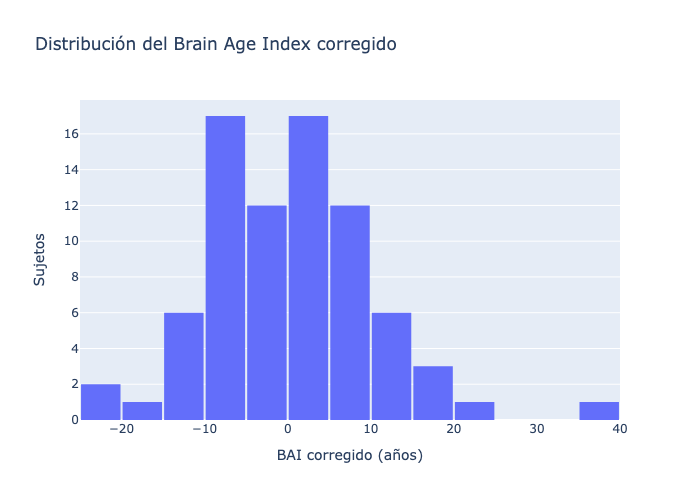

In [24]:
pendiente, intercepto = np.polyfit(y, bai, 1)
bai_corregido = bai - (pendiente * y + intercepto)

divergencia = pd.DataFrame({"subject": datos["subject"], "edad_real": y,
                            "edad_estimada": prediccion.round(1),
                            "bai": bai.round(1), "bai_corregido": bai_corregido.round(1)})

print(f"BAI sin corregir  - correlación con la edad: {stats.pearsonr(y, bai)[0]:+.3f}")
print(f"BAI corregido     - correlación con la edad: {stats.pearsonr(y, bai_corregido)[0]:+.3f}")
print(f"\nDesviación típica del BAI corregido: {bai_corregido.std():.1f} años\n")

print("Sujetos con mayor divergencia positiva (cerebro 'mayor' que su edad):")
print(divergencia.nlargest(5, "bai_corregido").to_string(index=False))
print("\nSujetos con mayor divergencia negativa (cerebro 'menor' que su edad):")
print(divergencia.nsmallest(5, "bai_corregido").to_string(index=False))

px.histogram(divergencia, x="bai_corregido", nbins=25,
             title="Distribución del Brain Age Index corregido",
             labels={"bai_corregido": "BAI corregido (años)"}
             ).update_layout(height=350, yaxis_title="Sujetos", bargap=0.05).show()

La corrección elimina la dependencia con la edad: la correlación del índice con la edad
cronológica pasa de −0,56 a 0,00, y su desviación típica queda en 10,4 años. Los sujetos que
más divergen lo hacen ahora por el contenido de su señal y no por su posición en el rango
etario, que es la condición necesaria para que el índice sirva como criterio de priorización.
